# Regression Model 1

This notebook implements regression models for predicting flow_duration. It uses the preprocessing decisions and train/test split from the regression preprocessing stage.

## Load Data and Split

We load the cleaned dataset and use the saved train/test indices to ensure reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Load cleaned dataset
df = pd.read_csv("../data/RT_IOT2022_cleaned.csv")
print("Dataset shape:", df.shape)

Dataset shape: (117922, 83)


In [2]:
# Load saved split indices
split_data = np.load("regression_split_indices.npz")
train_indices = split_data['train_indices']
test_indices = split_data['test_indices']

print(f"Train indices: {len(train_indices)}")
print(f"Test indices: {len(test_indices)}")

Train indices: 94337
Test indices: 23585


In [3]:
# Apply the same feature selection as preprocessing notebook
target = "flow_duration"

# Columns to drop (same as preprocessing)
drop_cols = []
timing_cols = [col for col in df.columns if 'iat' in col.lower()]
drop_cols.extend(timing_cols)
active_cols = [col for col in df.columns if col.startswith('active.')]
drop_cols.extend(active_cols)
idle_cols = [col for col in df.columns if col.startswith('idle.')]
drop_cols.extend(idle_cols)
rate_cols = ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second']
rate_cols = [col for col in rate_cols if col in df.columns]
drop_cols.extend(rate_cols)
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

df_reg = df.drop(columns=drop_cols)
print(f"Features after selection: {len(df_reg.columns)}")

Features after selection: 53


In [4]:
# Create engineered feature
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']
print("Created feature: total_packets")

Created feature: total_packets


In [5]:
# Split using saved indices
X = df_reg.drop(columns=[target])
y = df_reg[target]

X_train = X.loc[train_indices]
X_test = X.loc[test_indices]
y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (94337, 53)
X_test shape: (23585, 53)
y_train shape: (94337,)
y_test shape: (23585,)


In [6]:
# Identify categorical and numerical columns
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features: {cat_cols}")
print(f"Numerical features: {len(num_cols)}")

Categorical features: ['proto', 'service']
Numerical features: 51


## 1. Random Forest Regressor

Random Forest combines many decision trees. Each tree learns from different samples and features. The final regression prediction is based on the ensemble of trees. It can capture nonlinear relationships.

In [7]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Create Random Forest pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])

print("Random Forest pipeline created")

Random Forest pipeline created


In [8]:
# Train Random Forest
rf_pipeline.fit(X_train, y_train)
print("Random Forest training complete")

Random Forest training complete


In [9]:
# Predict and evaluate
y_pred_rf = rf_pipeline.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"R²: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")

Random Forest Results:
R²: 0.3383
RMSE: 47.7241
MAE: 1.5114


In [10]:
# Store results
results = []
results.append({
    'Model': 'Random Forest',
    'R2': r2_rf,
    'RMSE': rmse_rf,
    'MAE': mae_rf
})

results_df = pd.DataFrame(results)
print(results_df)

           Model        R2       RMSE       MAE
0  Random Forest  0.338325  47.724054  1.511416


### Random Forest Feature Importance

Extract and display feature importances from the Random Forest model.

In [11]:
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(f"Total features after encoding: {len(feature_names)}")

Total features after encoding: 64


In [12]:
# Get feature importances
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Create DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Display top features
print("Top 20 most important features:")
print(feature_importance_df.head(20))

Top 20 most important features:
                             feature  importance
15           remainder__fwd_pkts_tot    0.223551
17      remainder__fwd_data_pkts_tot    0.158836
20    remainder__fwd_header_size_tot    0.148524
29     remainder__fwd_PSH_flag_count    0.124871
14              remainder__id.resp_p    0.042440
30     remainder__bwd_PSH_flag_count    0.034237
52      remainder__fwd_subflow_bytes    0.022904
63          remainder__total_packets    0.021641
13              remainder__id.orig_p    0.021405
37   remainder__fwd_pkts_payload.tot    0.018672
49  remainder__flow_pkts_payload.std    0.014177
46  remainder__flow_pkts_payload.max    0.013855
36   remainder__fwd_pkts_payload.max    0.013138
56       remainder__fwd_bulk_packets    0.010947
41   remainder__bwd_pkts_payload.max    0.009878
19          remainder__down_up_ratio    0.009691
61   remainder__bwd_init_window_size    0.009488
54         remainder__fwd_bulk_bytes    0.009219
23    remainder__bwd_header_size_tot 

## 2. Gradient Boosting Regressor

Gradient Boosting builds trees sequentially. Each new tree tries to improve the errors made by previous trees. It can model nonlinear relationships.

In [13]:
# Create Gradient Boosting pipeline
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42, n_estimators=100))
])

print("Gradient Boosting pipeline created")

Gradient Boosting pipeline created


In [14]:
# Train Gradient Boosting
gb_pipeline.fit(X_train, y_train)
print("Gradient Boosting training complete")

Gradient Boosting training complete


In [15]:
# Predict and evaluate
y_pred_gb = gb_pipeline.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(f"R²: {r2_gb:.4f}")
print(f"RMSE: {rmse_gb:.4f}")
print(f"MAE: {mae_gb:.4f}")

Gradient Boosting Results:
R²: -0.1466
RMSE: 62.8243
MAE: 1.9760


In [16]:
# Add Gradient Boosting results to the table
results.append({
    'Model': 'Gradient Boosting',
    'R2': r2_gb,
    'RMSE': rmse_gb,
    'MAE': mae_gb
})

results_df = pd.DataFrame(results)
print("Model Comparison:")
print(results_df)

Model Comparison:
               Model        R2       RMSE       MAE
0      Random Forest  0.338325  47.724054  1.511416
1  Gradient Boosting -0.146636  62.824299  1.975976


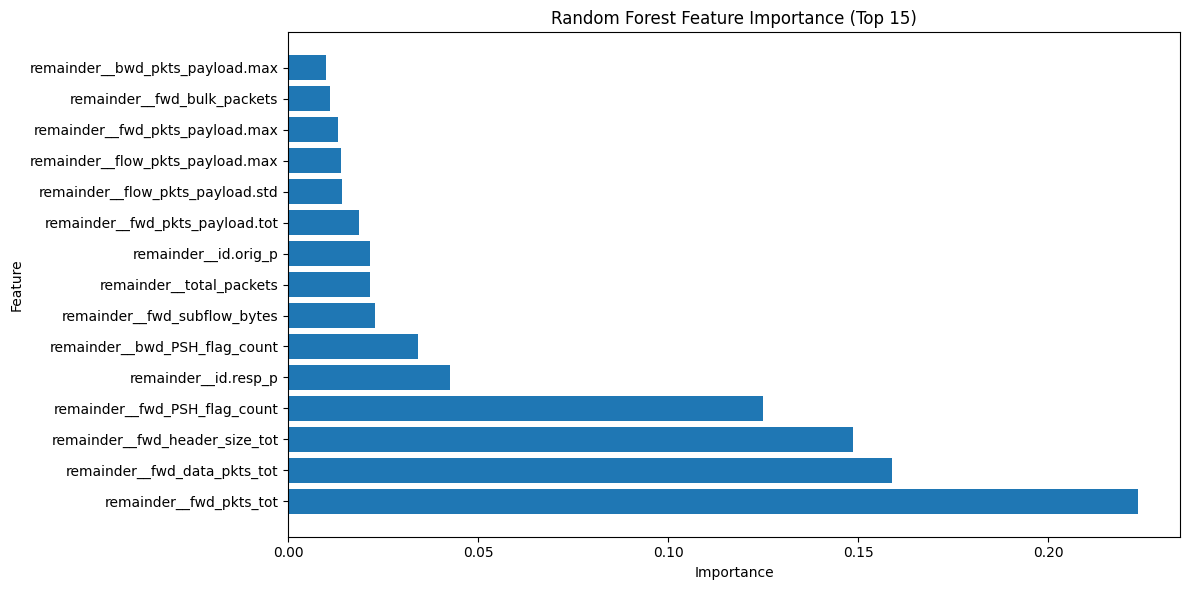

In [17]:
# Plot feature importances
plt.figure(figsize=(12, 6))
top_features = feature_importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance (Top 15)')
plt.tight_layout()
plt.show()